In [168]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ace_tools_open import display_dataframe_to_user

# Loading the Data

In [169]:
raw_path = r"D:\Data Science\cardiovascular-disease-prediction\data\raw"
df_cvd = pd.read_csv(raw_path  + r"\cardio_train.csv", delimiter = ";")

processed_path = r"D:\Data Science\cardiovascular-disease-prediction\data\processed"
df_cvd.to_csv(processed_path + r"\tabular_cvd.csv")

# Exploratory Data Analysis (EDA)

### Preview Data

In [170]:
display_dataframe_to_user('First 10 Rows of the Dataset', df_cvd.head(10))

First 10 Rows of the Dataset


Loading ITables v2.4.4 from the internet... (need help?)


### Dataset Shape

In [171]:
print("Dataset shape (rows, columns):", df_cvd.shape)

Dataset shape (rows, columns): (70000, 13)


### Data types overview

In [172]:
dtypes_df = df_cvd.dtypes.reset_index()
dtypes_df.columns = ['column', 'dtype']
display_dataframe_to_user('Data Types of Each Column', dtypes_df)

Data Types of Each Column


Loading ITables v2.4.4 from the internet... (need help?)


### Summary statistics for numeric features

In [173]:
target_col = 'cardio'
id_col = 'id'
numeric_cols = [c for c in df_cvd.select_dtypes(include=[np.number]).columns if c not in [target_col, id_col]]
desc_df = df_cvd[numeric_cols].describe().transpose().reset_index().rename(columns={'index':'feature'})
display_dataframe_to_user('Summary Statistics for Numerical Features', desc_df)

Summary Statistics for Numerical Features


Loading ITables v2.4.4 from the internet... (need help?)


In [174]:
df_cvd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


### Missing values per column

In [175]:
missing_df = df_cvd.isnull().sum().reset_index()
missing_df.columns = ['column', 'missing_count']
display_dataframe_to_user('Missing Values per Column', missing_df)


Missing Values per Column


Loading ITables v2.4.4 from the internet... (need help?)


### Distribution of target variable

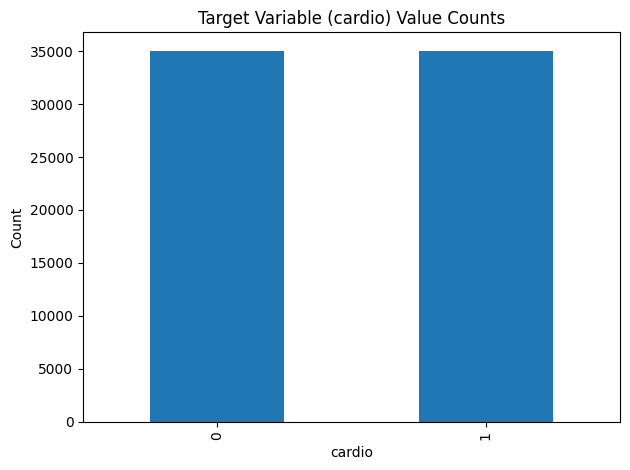

In [176]:
plt.figure()
df_cvd[target_col].value_counts().plot(kind='bar')
plt.title('Target Variable (cardio) Value Counts')
plt.xlabel(target_col)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Histogram for numerical features

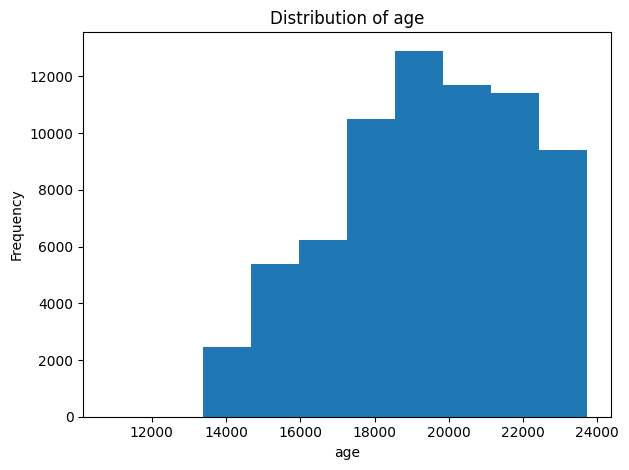

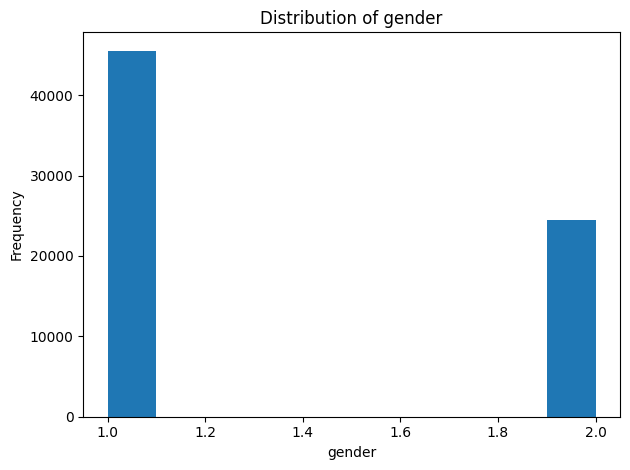

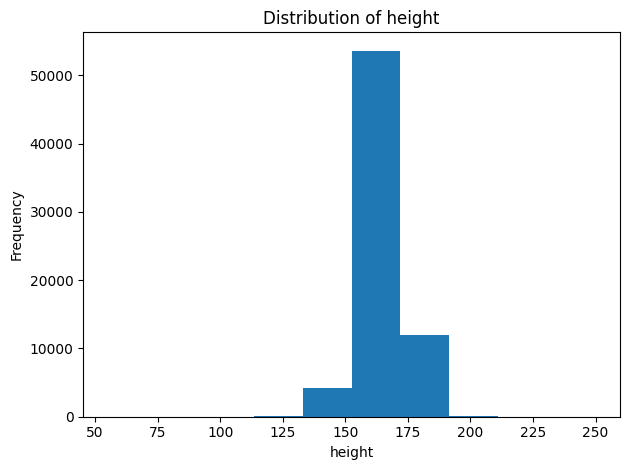

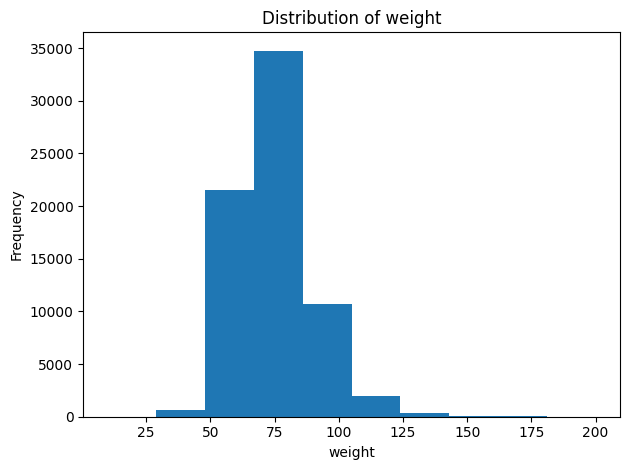

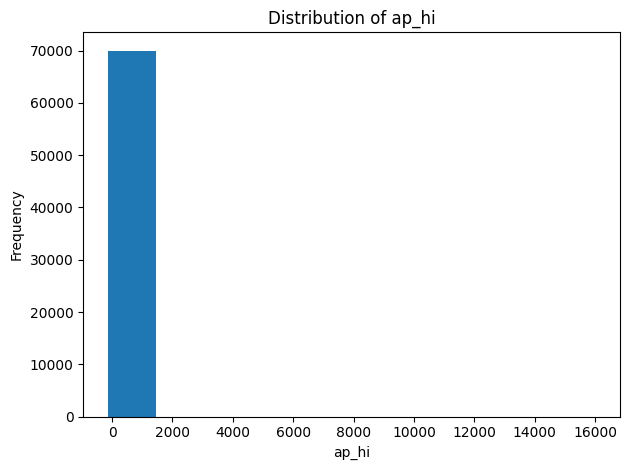

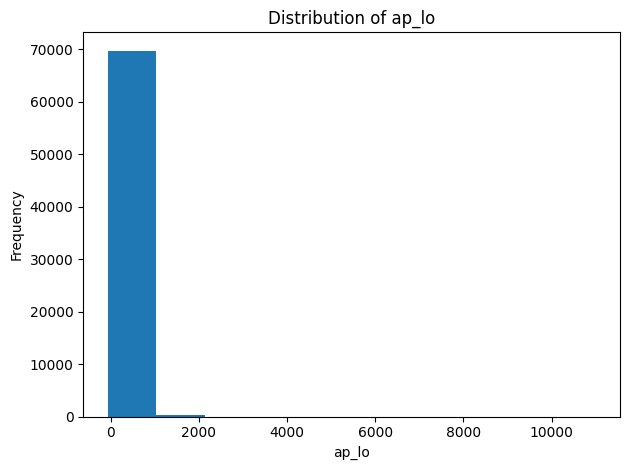

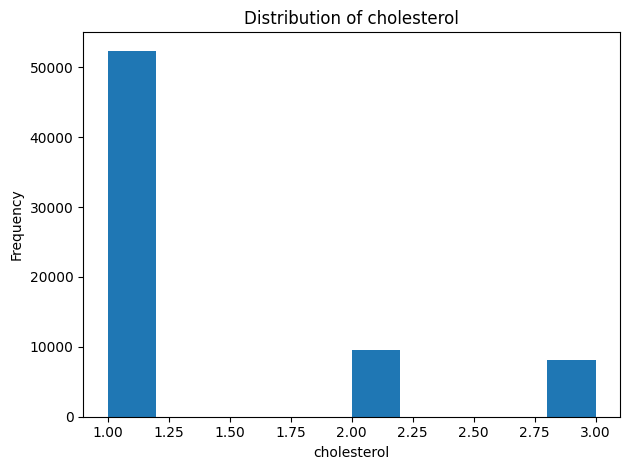

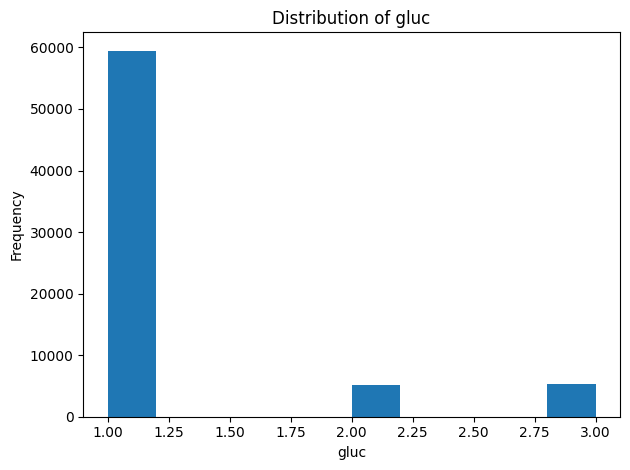

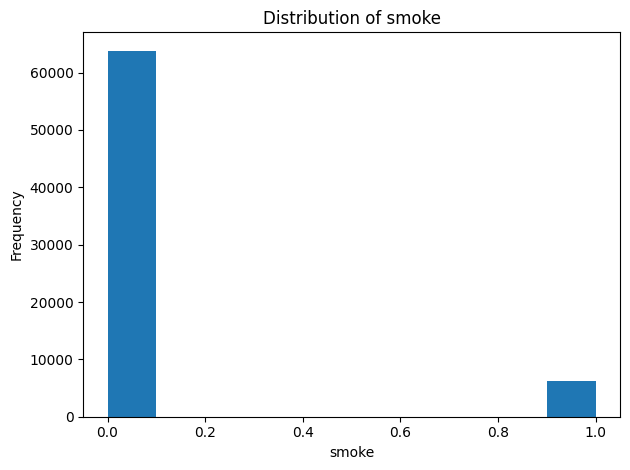

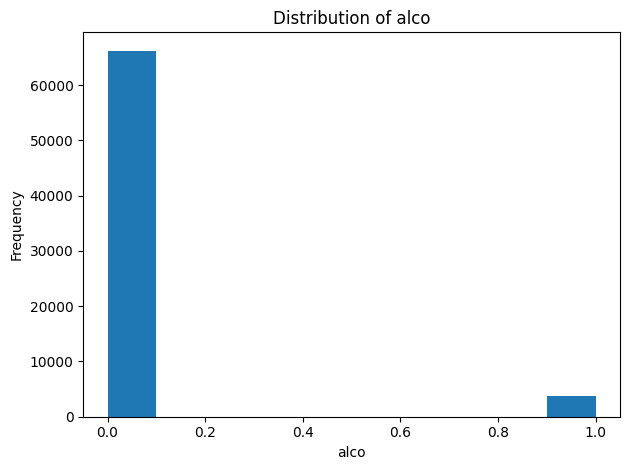

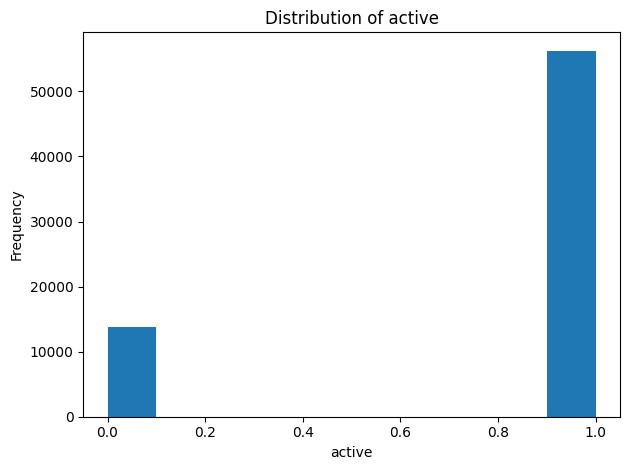

In [177]:
for col in numeric_cols:
    plt.figure()
    plt.hist(df_cvd[col].dropna())
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Box-plot for numeric variables

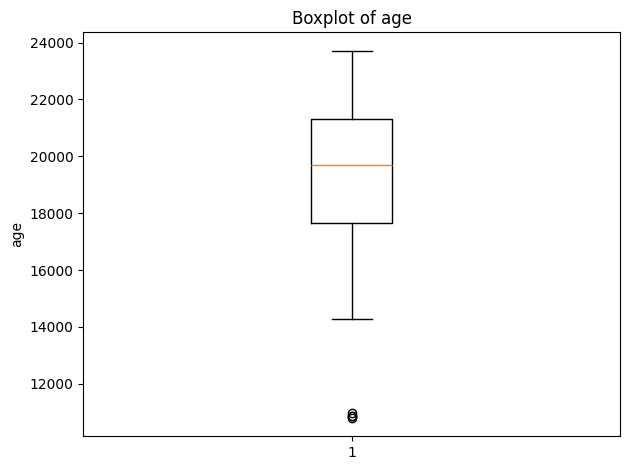

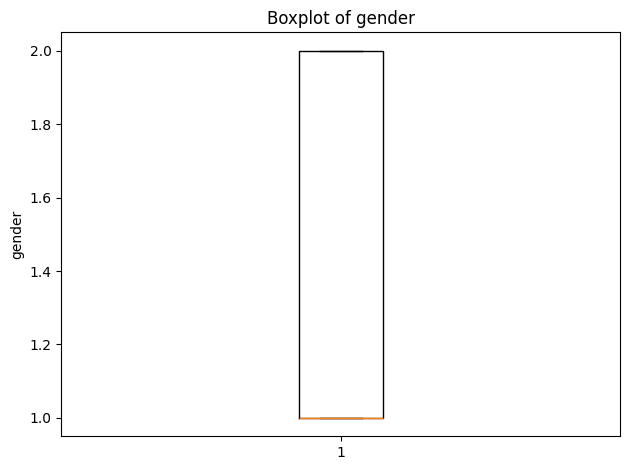

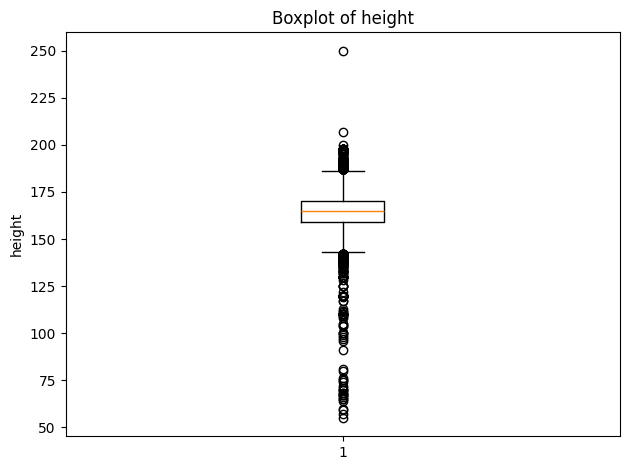

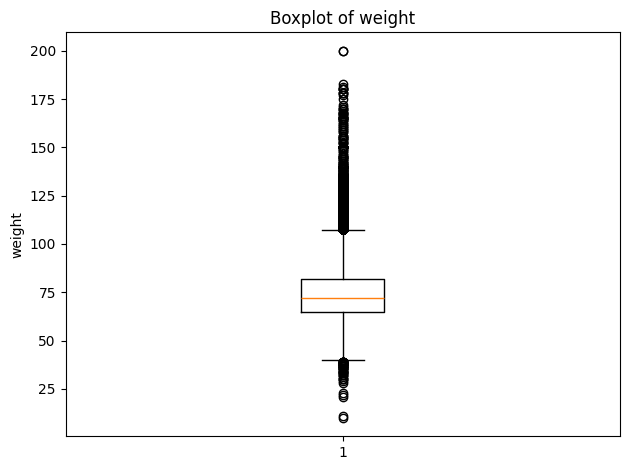

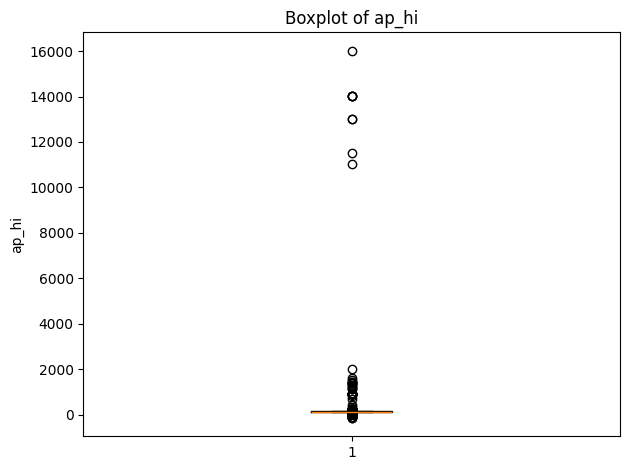

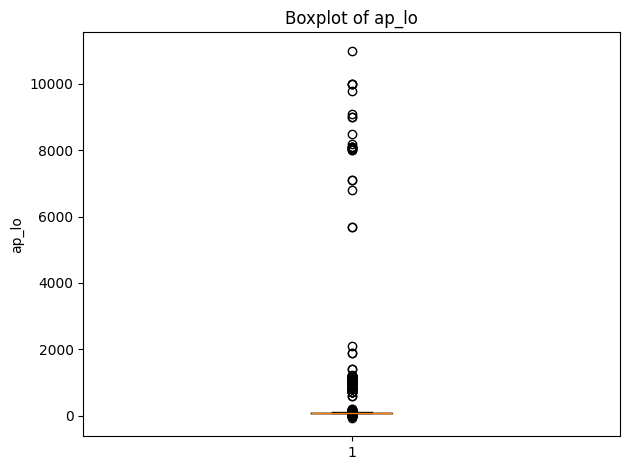

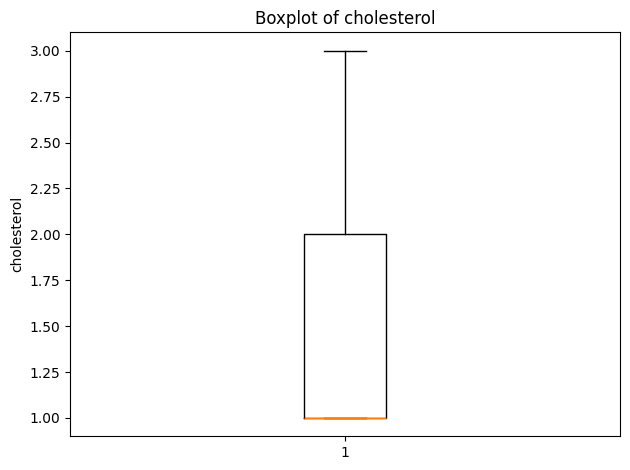

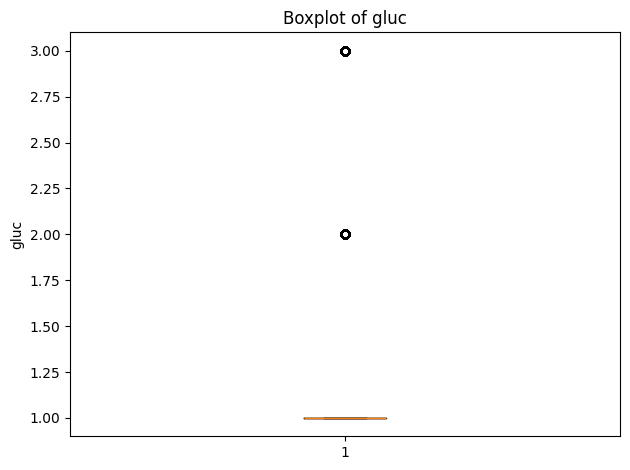

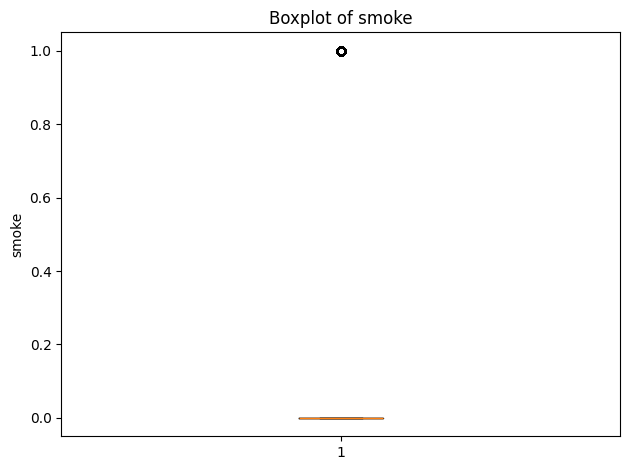

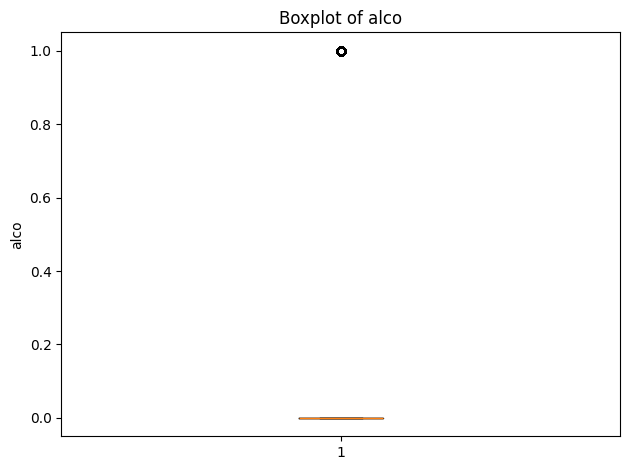

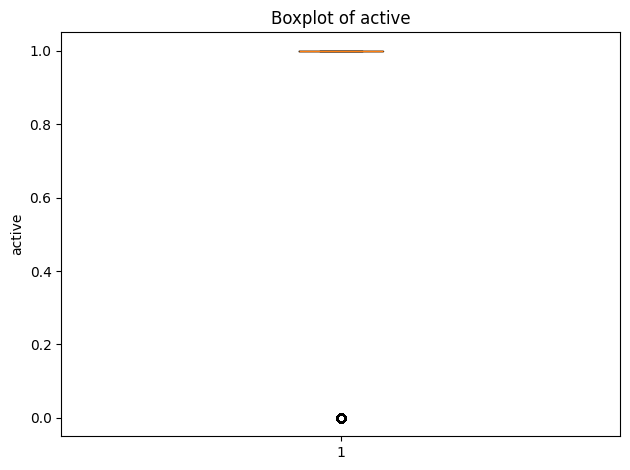

In [178]:
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df_cvd[col].dropna(), vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Value counts for categorical features

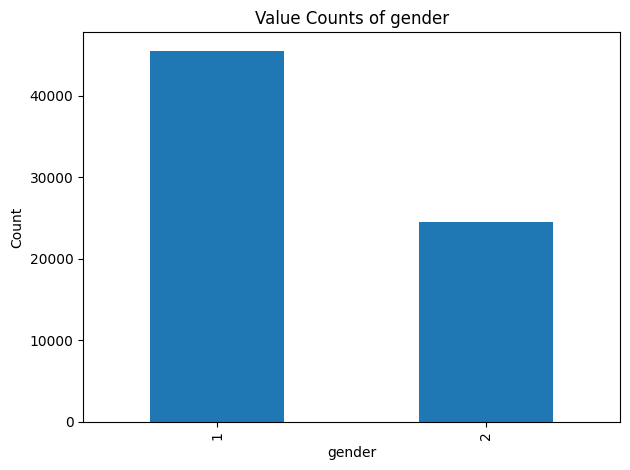

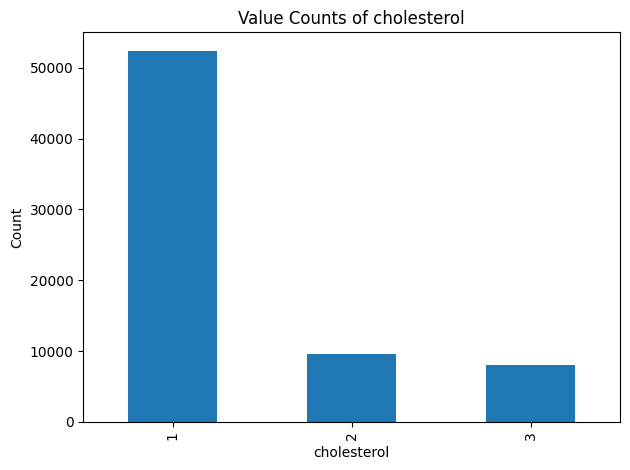

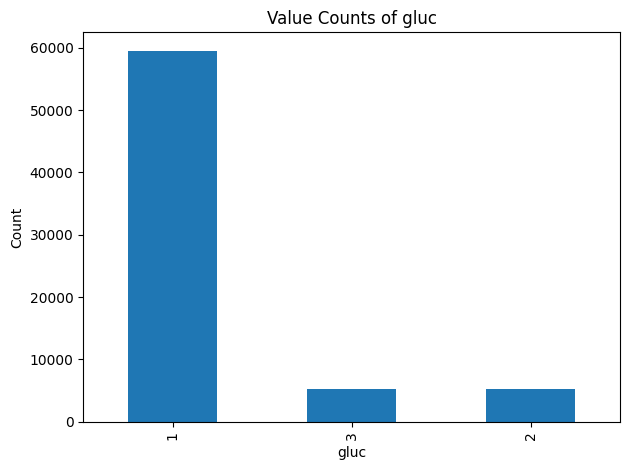

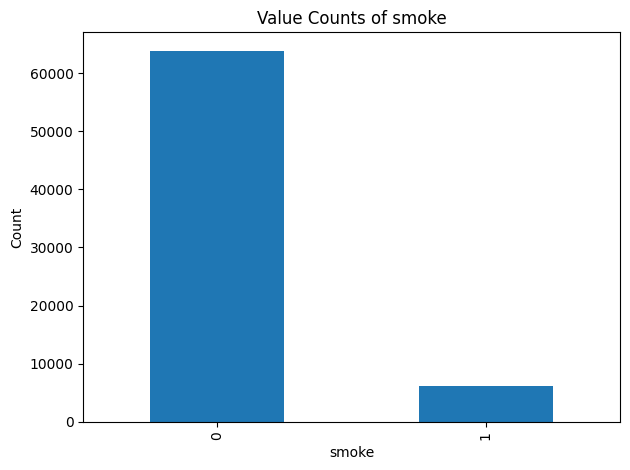

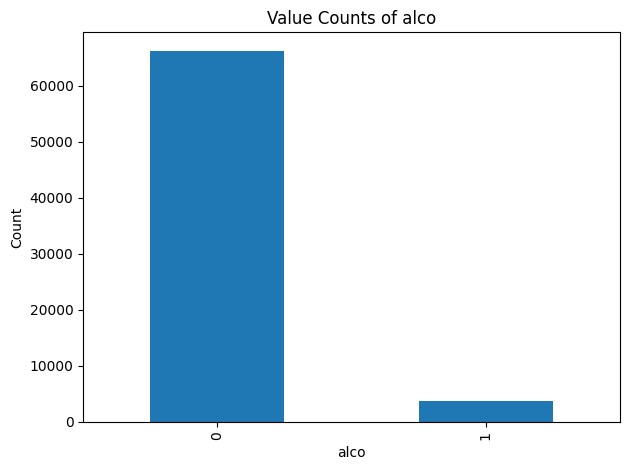

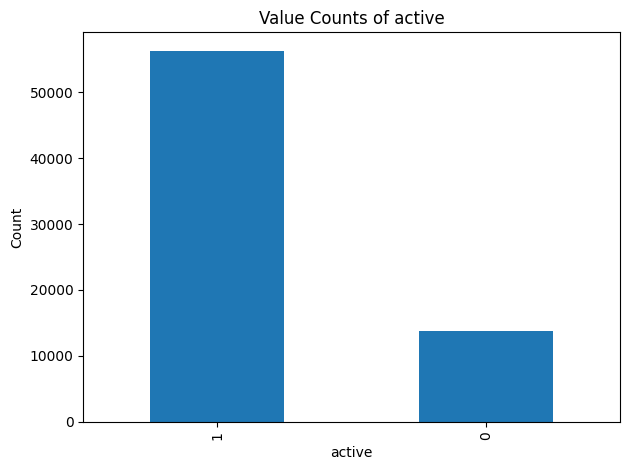

In [179]:
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
for col in categorical_cols:
    if col in df_cvd.columns:
        plt.figure()
        df_cvd[col].value_counts().plot(kind='bar')
        plt.title(f'Value Counts of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

### Correlation matrix heatmap

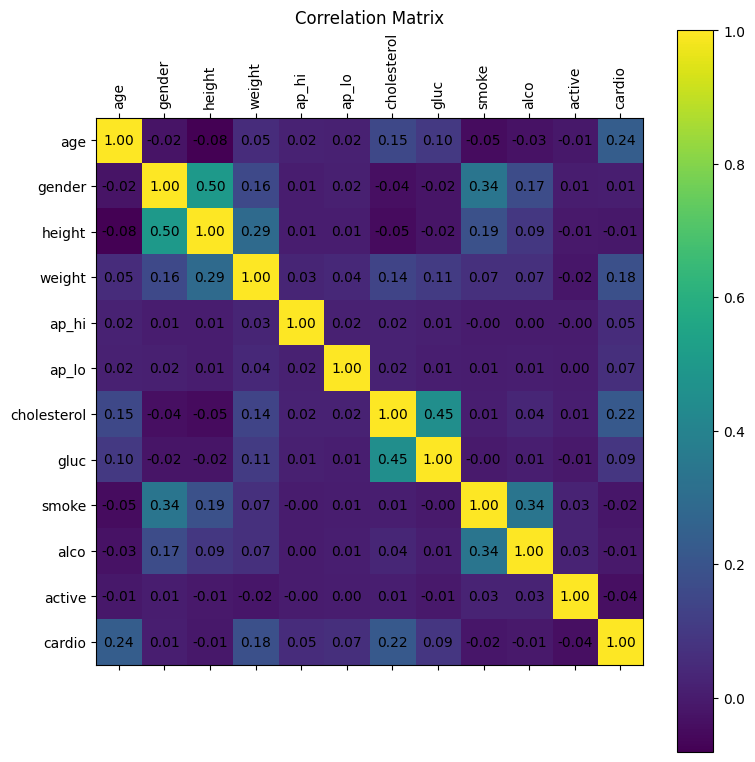

In [180]:
corr = df_cvd[numeric_cols + [target_col]].corr()
fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr, interpolation='nearest')
fig.colorbar(cax)
tick_marks = np.arange(len(corr.columns))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
for (i, j), val in np.ndenumerate(corr.values):
    ax.text(j, i, f"{val:.2f}", ha='center', va='center')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Data Cleaning

### Dropping Duplicates

In [181]:
initial_shape = df_cvd.shape

In [182]:
df_cvd.drop_duplicates()
print(f"Dropped {initial_shape[0] - df_cvd.shape[0]} duplicate rows")

Dropped 0 duplicate rows


### Handling Missing Values

In [183]:
missing = df_cvd.isnull().sum()
print("Missing values per column:\n", missing)

Missing values per column:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### Outlier Check - Checking for value consistency

In [184]:
cat_col = ['gender','cholesterol','gluc','smoke','alco','active']
for col in cat_col:
    print(df_cvd[col].value_counts())

gender
1    45530
2    24470
Name: count, dtype: int64
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64
gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64
smoke
0    63831
1     6169
Name: count, dtype: int64
alco
0    66236
1     3764
Name: count, dtype: int64
active
1    56261
0    13739
Name: count, dtype: int64


### Outlier Check - Finding range of continuous values

In [185]:
con_col  = ['age','height','weight','ap_hi','ap_lo']
df_cvd[con_col].describe()

,age,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,164.359229,74.205690,128.817286,96.630414
std,2467.251667,8.210126,14.395757,154.011419,188.472530
min,10798.000000,55.000000,10.000000,-150.000000,-70.000000
25%,17664.000000,159.000000,65.000000,120.000000,80.000000
50%,19703.000000,165.000000,72.000000,120.000000,80.000000
75%,21327.000000,170.000000,82.000000,140.000000,90.000000
max,23713.000000,250.000000,200.000000,16020.000000,11000.000000


#### Remove Negative values in ap_hi and ap_lo

In [186]:
neg_out = df_cvd[(df_cvd['ap_hi'] <= 0) | (df_cvd['ap_lo'] <= 0)]
neg_ind = neg_out.index
df_cvd = df_cvd.drop(neg_ind)

print(f"Dropped {neg_out.count()} negative values and zeroes from dataset")


Dropped id             29
age            29
gender         29
height         29
weight         29
ap_hi          29
ap_lo          29
cholesterol    29
gluc           29
smoke          29
alco           29
active         29
cardio         29
dtype: int64 negative values and zeroes from dataset


#### Remove outliers

In [195]:
df_cvd_cleaned = df_cvd[(df_cvd['ap_hi'].between(30,260)) & (df_cvd['ap_lo'].between(30,200))]

### Check for positive outliers

Text(0.5, 1.0, 'Distribution of ap_hi')

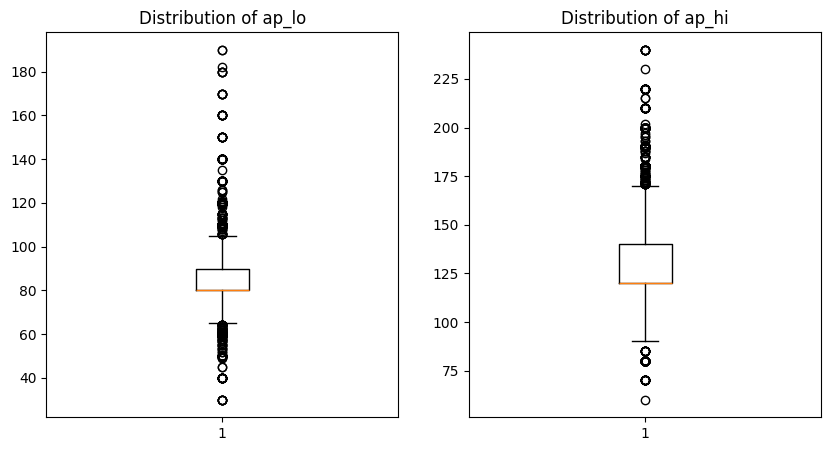

In [217]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))
# Box=plot for ap_lo

ax1.boxplot(df_cvd_cleaned['ap_lo'])
ax1.set_title("Distribution of ap_lo")


# Box=plot for ap_hi

ax2.boxplot(df_cvd_cleaned['ap_hi'])
ax2.set_title("Distribution of ap_hi")


### Check Frequency of Distribution

Text(0.5, 1.0, 'Frequency of ap_hi')

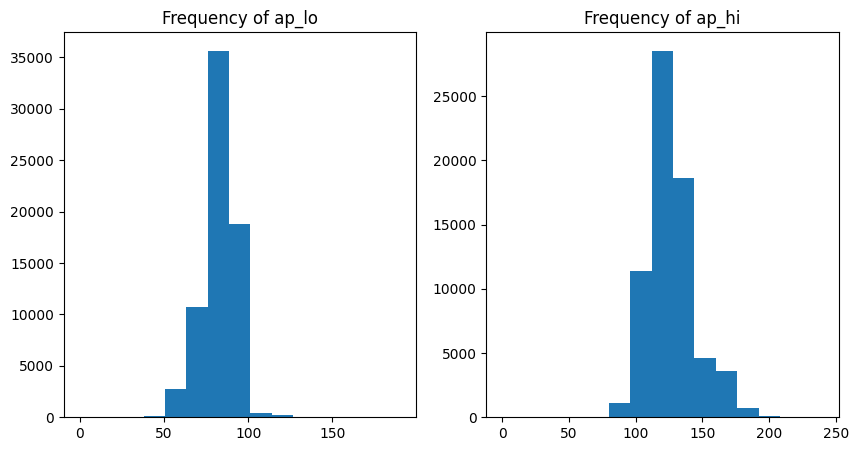

In [219]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

ax1.hist(df_cvd_cleaned.ap_lo, range=[0,df_cvd_cleaned.ap_lo.max()], bins = 15 )
ax1.set_title("Frequency of ap_lo")


ax2.hist(df_cvd_cleaned.ap_hi, range=[0,df_cvd_cleaned.ap_hi.max()], bins = 15 )
ax2.set_title("Frequency of ap_hi")


In [220]:
print("Shape after cleaning:", df_cvd_cleaned.shape)

Shape after cleaning: (68781, 13)


<Figure size 600x400 with 0 Axes>

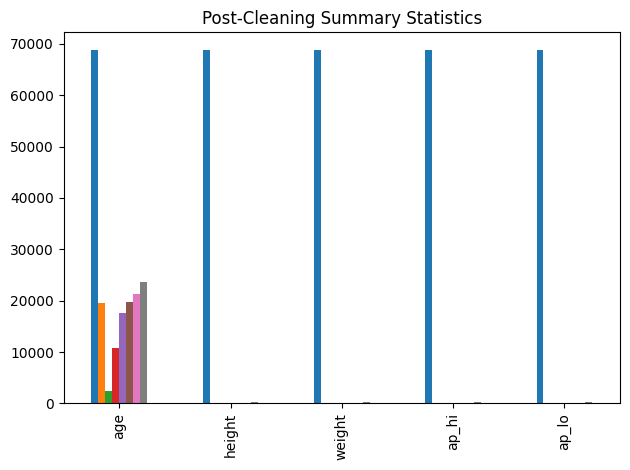

In [221]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df_cvd_cleaned[['age', 'height', 'weight', 'ap_hi', 'ap_lo']].describe().transpose().plot(kind='bar', legend=False)
plt.title("Post-Cleaning Summary Statistics")
plt.tight_layout()
plt.show()

# Feature Engineering